# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [19]:
NAMEs = ["Ryan", "Adaleia", "Joshua"]

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

**Predicting seismic building response is important because it helps with post-event damage evaluation. This allows FEMA to accurately asses that damages and send the right amount of support to the areas with catastrophic earthquake damages. The support could include cost estimates for repairs or even measuring the right amount of emergency responders to send to the location of the emergency.**

**The dataset of this study would be well suited for a machine learning approach because of the diversity of the data and how large the dataset is. Also because these features interact nonlinearly and many buildings lack the detailed design data that physics-based models need, an ML model can capture relationships that simple regression misses and still deliver fast predictions from just a few easy-to-obtain inputs.**

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

**Support vector regression fits a function through the data that is allowed to miss each point by a small tolerance (ε), so only points falling outside that tolerance band or called the "support vectors," influence the model. To handle complex relationships among many inputs, it uses a kernel function (like the Gaussian kernel in the paper) to map the data into a higher-dimensional space where a flat, simple fit there becomes a flexible nonlinear curve in the original inputs.**



Explaining Formulas (1) - (11)

Setup: You will have training points (x,y), where x is the feature vector and y is the true maximum drift ration=. The model is f(x) = Wᵀ·Φ(x) + b which is just a weighted sum of transformed features plus an offset. 

Formula (1) = |f(xᵢ) − yᵢ| ≤ ε
What its saying. We don't need a perfect fit. Any prediction within ±ε of the truth counts as good enough. This defines a tube around the fitted function.

Formula (2) = ½ΣEᵢ + (λ/2)‖W‖²
What its saying. Its minimizing two things at once the total error (Eᵢ) and model complexity (‖W‖²). Small weights mean a smoother function that is less likely to overfit. λ sets the balance between the two.

Formula (3) = Eᵢ = 0 if the error is within ε; otherwise the error minus ε.
What its saying. The points inside the support vector tube cost nothing and points outside are penalized only for how far the stick out past the edge. This is what makes SVR ignore small noise. 

Formula (4) = ½‖W‖² + C Σ(ξᵢ + ξᵢ*)
What its saying. Its formula 2 rewritten in standard SVR form. Since some points fall outside the tube, we give each one a "slack" (ξᵢ above the tube, ξᵢ* below) and penalize the total slack. C is the strictness dial a large C punishes outliers heavily  and small C tolerates them.

Formula (5) = f(xᵢ) − yᵢ ≤ ε + ξᵢ, yᵢ − f(xᵢ) ≤ ε + ξᵢ*, ξ ≥ 0
What its saying. This is what the slack variables mean. A prediction may overshoot or undershoot by ε plus its slack, and slack can never be negative. For a point inside the tube, ξ = 0.

Formula (6) = The Lagrangian
What its saying. Formula 4 is a constrained optimization problem. The Lagrangian folds the constraints (Formula 5) into the objective by attaching a multiplier (α, β, γ, γ*) to each one.

Formula (7) = W = Σ(αᵢ − βᵢ)Φ(xᵢ)
What its saying. setting the derivative of the Lagrangian with respect to W to zero shows that the optimal weights are just a weighted sum of the training points. Points with αᵢ = βᵢ = 0 (those inside the tube) drop out entirely. And the remaining points are the support vectors.

Formula (8) = Σ(αᵢ − βᵢ) = 0
What its saying. What you get from differentiating with respect to b. The push up or push down influences of the support vectors must cancel, so the fit isnt shifted overall. 

Formula (9) = αᵢ + γᵢ = βᵢ + γᵢ* = C
What its saying. What you get from differentiating with respect to ξ. It means 0 ≤ αᵢ, βᵢ ≤ C, so no single point can have more than C worth of influence. This is how C limits the influence of outliers.

Formula (10) = b = yⱼ − Σ(αᵢ − βᵢ)k(xᵢ, xⱼ) + ε
What its saying. Once the α's and β's are known, pick any support vector xⱼ that sits exactly on the tube's edge and solve for b so the fit passes through it. The kernel k appears here because Φ was never computed explicitly.

Formula (11) = f(x) = Σ(αᵢ − βᵢ) k(xᵢ, x) + b
What its saying. To predict for a new input x, compare it with each support vector using the kernel k (a similarity score), then take a weighted sum of those similarities and add b. This is the "kernel trick": k(xᵢ, xⱼ) = Φ(xᵢ)ᵀΦ(xⱼ) gives you the dot product in the high-dimensional feature space without ever computing Φ.



## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [20]:
import pandas as pd
import numpy as np

df = pd.read_excel("data_lab02.xlsx")

# index 0 are the column names so we need ot replace that index and drop it from the dataframe
# also the second row in the data are just the units of the data so we need to drop that as well.
df.columns = df.iloc[0]
df = df.drop(df.index[0, 1]).reset_index(drop=True)


# drop the columns that are not needed for the analysis
drop_columns = ['Network','Building ID', "Soil info.", 'Vs30', 'Typology', 'Event Date', 'PTA', 'PTV', 'PTD' , 'Effective']
df = df.drop(columns=drop_columns)
df.head()

,B_Lat.,B_Long.,Height,No. of story,E_Lat.,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,...,Uniform [0.15g],Bracketed [0.2g],Uniform [0.2g],Significant_a1 [(5-75)%],Significant_a2 [(5-95)%],Significant_v1 [(5-75)%],Significant_v2 [(5-95)%],Significant_d1 [(5-75)%],Significant_d2 [(5-95)%],ZX
0,36.132,140.073,3400,8,34.03,136.2283,5.3,420.7,1.577005,0.073452,...,0,0,0,54.89,73.15,56.97,81.65,93.23,122.2,54.300537
1,36.132,140.073,3400,8,36.1067,139.8917,3.8,16.6,3.449968,0.132411,...,0,0,0,5.96,19.57,13.88,27.74,25.26,63.18,6.934593
2,36.132,140.073,3400,8,37.02,141.0583,4.2,132.2,0.854165,0.036735,...,0,0,0,10.6,29.11,18.58,48.81,70.65,72.53,5.923775
3,36.132,140.073,3400,8,36.045,140.0867,3.4,9.8,0.549761,0.026009,...,0,0,0,10.45,25.24,13.61,32.37,33.76,57.79,5.139623
4,36.132,140.073,3400,8,35.46,140.7517,5.7,96.6,5.863478,1.006804,...,0,0,0,24.25,48.01,23.06,50.12,28.47,70.65,20.686939


In [21]:
# check for missing values in the dataframe
df.isnull().sum()

0
B_Lat.                        0
B_Long.                       0
Height                        0
No. of story                  0
E_Lat.                        0
E_Long.                       0
Magnitude                     0
Epicentral distance (R)       0
PGA                           0
PGV                           0
PGD                           0
AI                            0
DP                            0
CAV                           0
SA1                           0
SV1                           0
SD1                           0
SA2                           0
SV2                           0
SD2                           0
Drift                         0
F1                            2
F2                            0
Avg_Sa                        2
Avg_Sv                        2
Avg_Sd                        2
Bracketed 1 [0.05g]         583
Uniform [0.05g]             583
Bracketed [0.1g]            583
Uniform [0.1g]              583
Bracketed [0.15g]           583
Unifor

In [22]:
# We will remove the missing values from the dataframe there are only around 500 when the amount of the data is 12,000 so it is not a huge data loss.
df = df.dropna().reset_index(drop=True)

# was told by a group member that there is an outlier in the Drift variable so we will remove that outlier from the dataframe
df = df.drop(index=6240).reset_index(drop=True)


In [23]:
# Target variable and input variables
X = df.drop(columns=['Drift'])
y = df['Drift'].astype(float)

b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

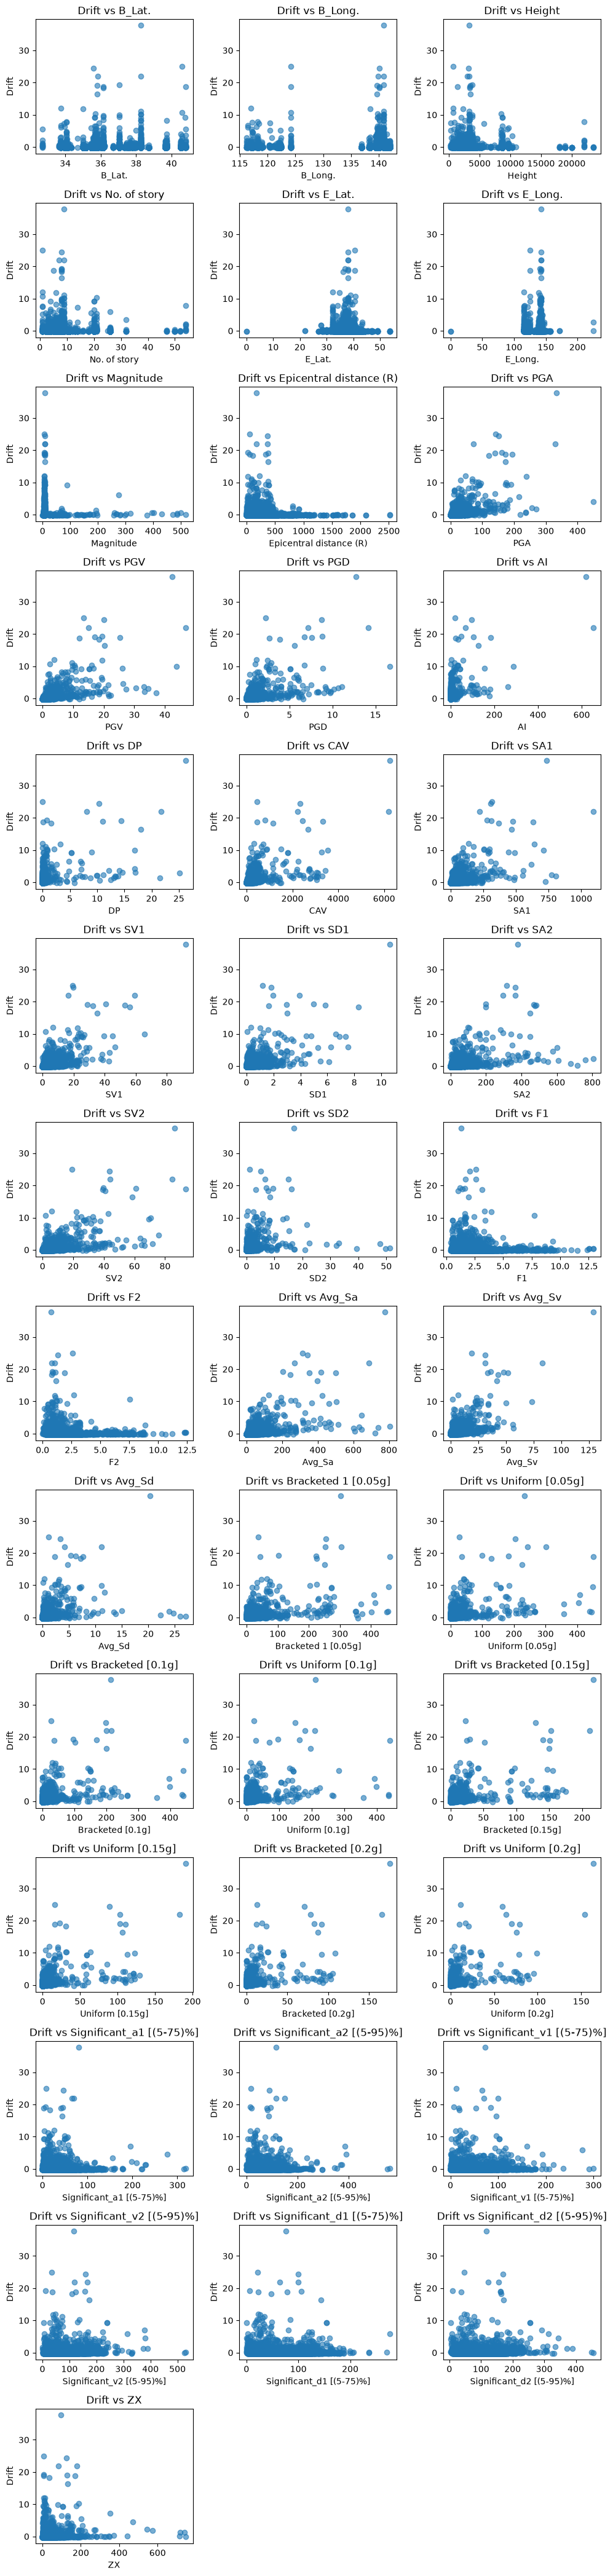

In [24]:
# creating scatterplots between the target variable and each of the input variables to see if there is any correlation between them.
import matplotlib.pyplot as plt

# make the layout of the plots more compact and next to each other 
n_cols = 3
n_rows = (len(X.columns) + n_cols - 1) // n_cols

plt.figure(figsize=(10, 3 * n_rows))

## add R-squared value to the scatterplots
for index, col in enumerate(X.columns):
    plt.subplot(n_rows, n_cols, index + 1)
    plt.scatter(X[col], y, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("Drift")
    plt.title(f"Drift vs {col}")

plt.tight_layout()
plt.show()
    

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?


The scatterplots show that Drift is highly right-skewed. Most observations have relatively small drift values, while a smaller number of observations have much larger values. Many predictors also show clustered and nonlinear patterns rather than a clear straight-line relationship, so a nonlinear model like SVR will be useful.

The ground-motion intensity features appear to be potentially the most influential predictors. In particular, PGA, PGV, PGD, SA1, SA2, Avg_Sa, Avg_Sv, and the significant-duration variables show greater variation in Drift and more high-drift observations at larger values. Building characteristics such as Height and the number of stories may also be important, although their relationships with Drift do not appear strictly linear. Variables such as Magnitude and Epicentral distance show weaker visual relationships.

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [25]:
# import all my packages.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer


In [26]:
# split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#make pipeline for scaling the data and fitting the SVR model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svr', SVR())
])


In [27]:
# define the inner cross-validation for hyperparameter tuning
cv_inner = KFold(n_splits=10, shuffle=True, random_state=42)

# define the parameter grid for the SVR model
param_grid = [
    {'svr__kernel': ['linear'], 'svr__C': [0.1, 1]},
    {'svr__kernel': ['rbf'], 'svr__C': [10, 30, 100, 150],
     'svr__gamma': [0.0001, 0.0005, 0.001]}
]

# define the grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=cv_inner, scoring='r2', n_jobs=-1)

# fit the grid search to the training data
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svr__C': [0.1, 1], 'svr__kernel': ['linear']}, {'svr__C': [10, 30, ...], 'svr__gamma': [0.0001, 0.0005, ...], 'svr__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.

In [28]:
# print the best parameters and the best score from the grid search
print("Best parameters found: ", grid_search.best_params_)
print("Best R-squared score found: ", grid_search.best_score_)

Best parameters found:  {'svr__C': 100, 'svr__gamma': 0.0005, 'svr__kernel': 'rbf'}
Best R-squared score found:  0.5367360049599094


In [29]:
# evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# calculate the R2 score and MSE
r2_score_value = r2_score(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
print("R-squared score on test set: ", r2_score_value)
print("Mean Squared Error on test set: ", mse_value)


R-squared score on test set:  0.48621654624149524
Mean Squared Error on test set:  0.35030362342759896


**R² = 0.486**: the model explains about 49% of the variation in maximum inter-story drift across buildings and earthquakes it never saw during training. The other ~51% comes from things the features don't capture. 

**MSE = 0.35**: Drift is standardized, so this is in squared standard-deviation units. Taking the square root gives an RMSE of about 0.59 SD, meaning a typical prediction misses by about 0.6 of a standard deviation of Drift. That's large relative to most drift values, which cluster tightly near the bottom of the range. The error is concentrated in the few high-drift buildings.

**Test vs. CV**: a test R² of 0.486 is close to your cross-validation score of about 0.50. So the model isn't overfitting, and 0.49 is an honest estimate of how it performs on new data.


b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [30]:
# Now we will use Kernal Ridge regression to see if we can get better predictions than the SVR model. 
# We will use the same pipeline and parameter grid as we did for the SVR model.
# We will also use the same inner cross-validation for hyperparameter tuning.
from sklearn.kernel_ridge import KernelRidge


In [31]:
#create a pipeline for scaling the data and fitting the KRR model
pipeline_krr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('krr', KernelRidge())
])

In [32]:
# tune hyperparameters for the KRR model using grid search with cross-validation
inner_cv_krr = KFold(n_splits=10, shuffle=True, random_state=42)

param_grid_krr = [
    {'krr__kernel': ['linear'], 'krr__alpha': [0.1, 1, 10]},
    {'krr__kernel': ['rbf'], 'krr__alpha': [0.1, 1, 10], 'krr__gamma': [0.0001, 0.0005, 0.001]},
    {'krr__kernel': ['poly'], 'krr__alpha': [0.1, 1, 10], 'krr__degree': [2, 3]},
]
# define the grid search with cross-validation for KRR
grid_search_krr = GridSearchCV(pipeline_krr, param_grid_krr, cv=inner_cv_krr, scoring='r2', n_jobs=3)

#fit the grid search to the training data for KRR
grid_search_krr.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rnelRidge())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'krr__alpha': [0.1, 1, ...], 'krr__kernel': ['linear']}, {'krr__alpha': [0.1, 1, ...], 'krr__gamma': [0.0001, 0.0005, ...], 'krr__kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",3
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... vers

In [33]:
# print the best parameters and the best score from the grid search for KRR
print("Best parameters found for KRR: ", grid_search_krr.best_params_)
print("Best R-squared score found for KRR: ", grid_search_krr.best_score_)

Best parameters found for KRR:  {'krr__alpha': 0.1, 'krr__gamma': 0.0005, 'krr__kernel': 'rbf'}
Best R-squared score found for KRR:  0.5467544980913092


In [34]:
best_model_krr = grid_search_krr.best_estimator_
y_pred_krr = best_model_krr.predict(X_test) 

# calculate the R2 score and MSE for KRR
r2_score_value_krr = r2_score(y_test, y_pred_krr)
mse_value_krr = mean_squared_error(y_test, y_pred_krr)
print("R-squared score on test set for KRR: ", r2_score_value_krr)
print("Mean Squared Error on test set for KRR: ", mse_value_krr)


R-squared score on test set for KRR:  0.48572024736585306
Mean Squared Error on test set for KRR:  0.3506420058592804


c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

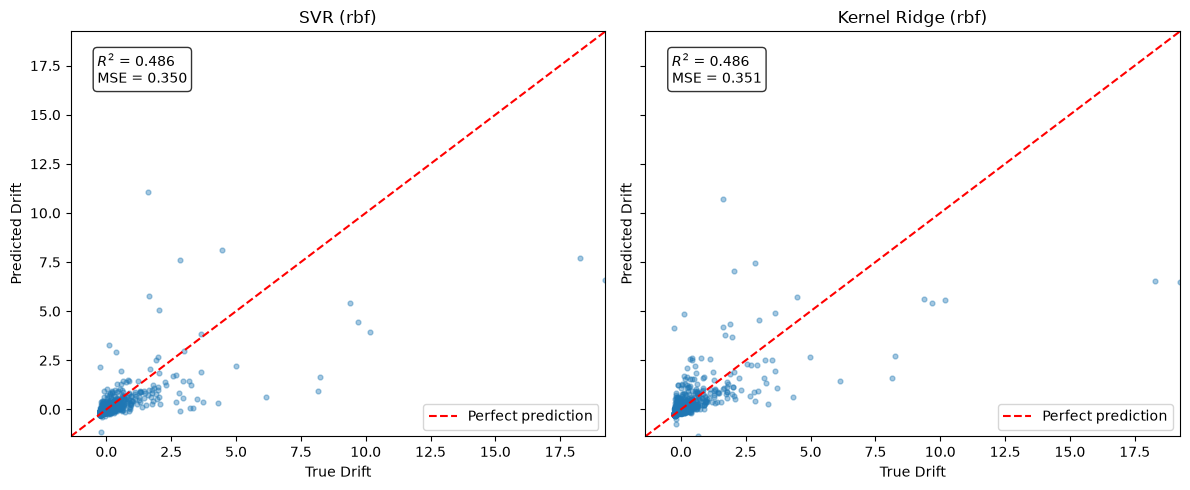

In [35]:
# predicted vs true scatterplots for SVR and KRR side by side
y_true = y_test.astype(float)
results = {
    "SVR (rbf)": (y_pred, r2_score_value, mse_value),
    "Kernel Ridge (rbf)": (y_pred_krr, r2_score_value_krr, mse_value_krr),
}

# same axis limits on both plots so they can be compared directly
lo = min(y_true.min(), y_pred.min(), y_pred_krr.min())
hi = max(y_true.max(), y_pred.max(), y_pred_krr.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (name, (preds, r2, mse)) in zip(axes, results.items()):
    ax.scatter(y_true, preds, alpha=0.4, s=12)
    ax.plot([lo, hi], [lo, hi], 'r--', label='Perfect prediction')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("True Drift")
    ax.set_ylabel("Predicted Drift")
    ax.set_title(name)
    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMSE = {mse:.3f}",
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


SVR and KRR perform almost identically on the reporting set. Both reach R² ≈ 0.486, with an MSE of 0.350 for SVR and 0.351 for KRR, and their predicted-vs-true plots show the same pattern. Low drift values are predicted well, with points clustered around the diagonal. The rare high-drift events (true Drift > 5) are badly under-predicted by both models and fall well below the perfect-prediction line. This is probably because Drift is heavily right-skewed, so the models see very few extreme examples during training. Since neither model is meaningfully more accurate, SVR is slightly preferable. It reaches the same performance while relying only on its support vectors, so it is sparser and cheaper to store and evaluate than KRR, which uses every training point.

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [ ]:
# [Your code here]

Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [ ]:
# [Your code here]

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [ ]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE